In [1]:
from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np

from algs.cd_loss2 import CDLoss
from algs.bases import MonomialBasis, BasisSpec, ChebyshevBasis
from algs.cd_poly import CDPolynomial

In [2]:
X, t = make_swiss_roll(n_samples=1000)
y = t < 7

In [3]:
X.shape, t.shape

((1000, 3), (1000,))

In [4]:
t.min()

4.742164198066529

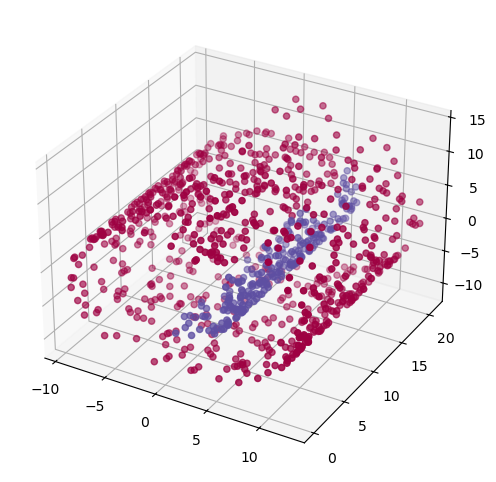

In [5]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=y, cmap=plt.cm.Spectral)
plt.show()

In [12]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(3, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 2),
            nn.BatchNorm1d(num_features=2)
            #nn.Tanh()
        )
        self.dec = nn.Sequential(
            nn.Linear(2, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 3)
        )

    def forward(self, x):
        z = self.enc(x)
        x_rec = self.dec(z)
        return x_rec, z
    
    @torch.no_grad()
    def encode(self, x):
        return self.enc(x)

In [13]:
x = torch.from_numpy(X.astype(np.float32))

In [43]:
model = Model()
opt = torch.optim.SGD(model.parameters(), lr=1e-2)
p = CDLoss(degree=3, n_vars=2, eps=1e-3, basis='mon')
dl = DataLoader(x[y], batch_size=len(x))

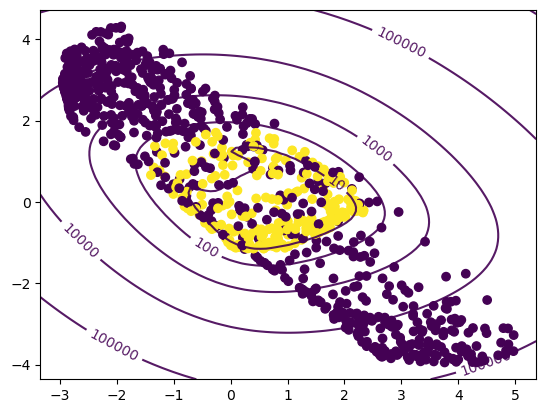

In [45]:
_,z = model(x)
plt.scatter(*z.detach().numpy().T, c=y)

q = CDPolynomial(z[y].detach().numpy(), degree=3)
q.plot(plt.gca())

78.34445190429688 79.9316177368164 1.1813552 -2.768521
6.334850e+02
78.1117935180664 79.26761627197266 1.4212345 -2.577056
3.245501e+03
77.20497131347656 78.70846557617188 1.313095 -2.8165889
4.665165e+02
76.79998779296875 78.11046600341797 1.3386396 -2.6491144
9.327781e+02
75.99713897705078 77.5629653930664 1.0934632 -2.6592877
3.106225e+02
75.50518035888672 77.03731536865234 1.237514 -2.769649
4.648574e+02
74.90534210205078 76.4668960571289 1.0423928 -2.6039515
4.733128e+02
74.42060089111328 75.97299194335938 1.166435 -2.7188268
4.665938e+02
73.7945327758789 75.40093231201172 1.0552044 -2.6616056
4.463669e+02
73.38970184326172 74.91508483886719 1.0841265 -2.6095119
4.240956e+02
72.62503051757812 74.32379913330078 0.9713116 -2.6700842
3.514779e+02
72.24246215820312 73.8089828491211 1.0365045 -2.603029
4.039655e+02
71.36229705810547 73.19517517089844 0.94814074 -2.7810228
7.435544e+02
71.1556167602539 72.67768096923828 0.9836952 -2.5057623
5.512151e+02
70.36212158203125 72.031715393066

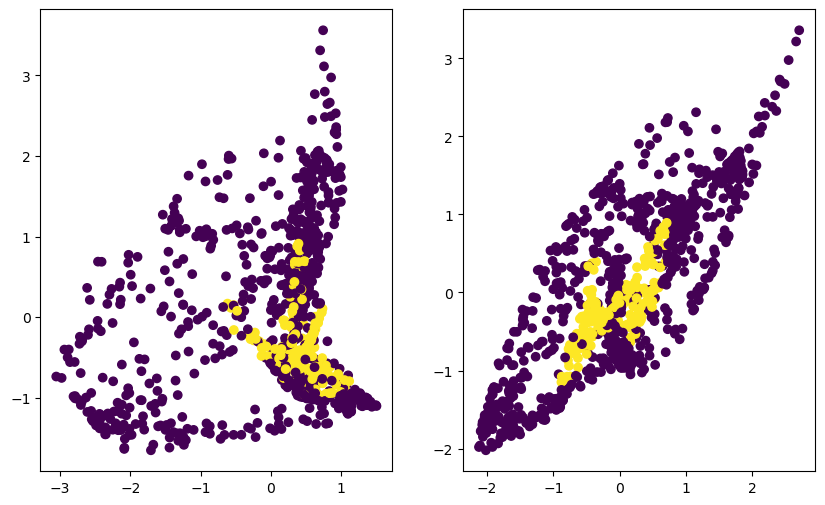

In [44]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 6))

bs = BasisSpec(n_vars = 2, degree=3)
cheb = ChebyshevBasis(bs)

for i in range(100):
    p.update_buffer(dl, model, device='cpu')

    x_rec, z = model(x)

    v = cheb.transform(z[y])

    if i == 0 or i == 1:
      ax[i].scatter(*z.detach().T, c=y)

    rec_loss = F.mse_loss(x_rec, x)
    in_loss = torch.log(p(z[y])).mean()
    out_loss = -torch.log(p(z[~y])).mean()
    #orth_loss = ((v.T @ v / len(z[y]) - torch.eye(10)) ** 2).mean()
    #in_loss = (z[y] ** 2).mean()
    #out_loss = -(z[~y] ** 2).mean()
    #in_loss = (z[y] ** 2).mean()
    loss = rec_loss + 1. * out_loss + 1. * in_loss

    opt.zero_grad()
    loss.backward()
    opt.step()

    print(loss.detach().item(),
          rec_loss.detach().item(),
          in_loss.detach().numpy(),
          out_loss.detach().numpy()
    )
    print(f'{torch.linalg.cond(p.M_buf):e}')

In [ ]:
    out_loss = -torch.log(p(z[~y])).mean()
    #orth_loss = ((v.T @ v / len(z[y]) - torch.eye(10)) ** 2).mean()
    #in_loss = (z[y] ** 2).mean()
    #out_loss = -(z[~y] ** 2).mean()
    #in_loss = (z[y] ** 2).mean()
    loss = 1 * out_loss + 1. * orth_loss

    opt.zero_grad()
    loss.backward()
    opt.step()

    print(loss.detach().item(),
          orth_loss.detach().numpy(),
          out_loss.detach().numpy()
    )
    print(f'{torch.linalg.cond(p.M_buf):e}')

In [648]:
z_rec.shape

torch.Size([1000, 3])